In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
import numpy as np
import matplotlib.pyplot as plt

class RegressionMLView:
    def __init__(self, l1_lambda=0, l2_lambda=0):
        self.W = None 
        self.B0 = None
        self.SSE = None
        self.MSE = None
        self.r_squared = None 
        self.l1 = l1_lambda
        self.l2 = l2_lambda

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)
        
        n_samples, n_features = X.shape
        self.W = np.zeros((n_features, 1))
        self.B0 = 0.0
        self.SSE = float('inf')

        for i in range(epochs):
            y_hat = np.dot(X, self.W) + self.B0
            error = y_hat - y 
            
            db0 = (2 / n_samples) * np.sum(error)
            dw_base = (2 / n_samples) * np.dot(X.T, error)
            
            dw = dw_base + (self.l1 / n_samples) * np.sign(self.W) + (2 * self.l2 / n_samples) * self.W
            
            self.B0 -= learning_rate * db0
            self.W -= learning_rate * dw
            
            current_sse = np.sum((y - (np.dot(X, self.W) + self.B0)) ** 2)
            
            if abs(self.SSE - current_sse) < tolerance:
                self.SSE = current_sse
                break
            self.SSE = current_sse

        self.MSE = self.SSE / n_samples
        # حساب R^2 للـ Training Data
        self.r_squared = self.score(X, y)
        
        if n_features == 1:
            self.B1_simple = self.W[0][0]

    def predict(self, X):
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.W) + self.B0

    def score(self, X, y):
        """حساب الـ R-squared"""
        y = np.array(y).reshape(-1, 1)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - (sse / sst)

    def plot(self, X, y):
        X_arr = np.array(X)
        if len(X_arr.shape) > 1 and X_arr.shape[1] > 1:
            print("Plotting is only supported for Simple Linear Regression.")
            return
            
        y_pred = self.predict(X_arr)
        plt.scatter(X, y, color='blue', label='Actual Data')
        plt.plot(X, y_pred, color='red', label=f'Model (R2={self.score(X,y):.3f})')
        plt.legend()
        plt.show()

In [5]:
df_train = pd.read_csv("train_processed.csv")

df_test = pd.read_csv("test_processed.csv")

In [11]:
# 1: Best Single Predictor
correlation_matrix = df_train.corr()
top_feature = correlation_matrix['FinalGrade'].sort_values(ascending=False).index[1] 

In [18]:
print(top_feature)

Attendance (%)


In [28]:
# Prepare training and testing data using only the selected top feature
X_train_1 = df_train[[top_feature]].values
X_test_1 = df_test[[top_feature]].values

In [12]:
# 2: Full Model
all_features = df_train.drop(columns=['FinalGrade']).columns.tolist()

In [29]:
# Prepare training and testing data using all available features
X_train_2 = df_train[all_features].values
X_test_2 = df_test[all_features].values

In [13]:
# 3: A domain-knowledge based selection
selected_features = ['PreviousGrade', 'Attendance (%)', 'StudyHoursPerWeek']

In [30]:
# Prepare training and testing data using only selected domain features
X_train_3 = df_train[selected_features].values
X_test_3 = df_test[selected_features].values

In [14]:
y_train = df_train['FinalGrade'].values
y_test = df_test['FinalGrade'].values

Case 1: Simple LR (Top Feature)

--- Case 1: Simple LR (Using: Attendance (%)) ---
Equation: y = 79.91 + 0.38 * Attendance (%)
Test MSE: 79.7839
Test R2: -0.0033


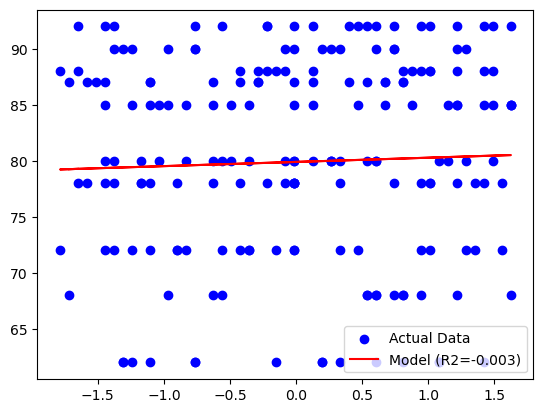

In [ ]:
# Initialize the regression model (no regularization)
model_1 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_1.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_1 = model_1.predict(X_test_1)

# Calculate evaluation metrics
mse_1 = np.mean((y_test.reshape(-1, 1) - y_pred_1)**2)  # Mean Squared Error
r2_1 = model_1.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 1: Simple LR (Using: {top_feature}) ---")
print(f"Equation: y = {model_1.B0:.2f} + {model_1.W.flatten()[0]:.2f} * {top_feature}")
print(f"Test MSE: {mse_1:.4f}")
print(f"Test R2: {r2_1:.4f}")

# Plot the regression line against the test data
model_1.plot(X_test_1, y_test)

Case 2: Full Model (All Features)


In [ ]:
# Initialize the regression model (no regularization)
model_2 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_2.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_2 = model_2.predict(X_test_2)

# Calculate evaluation metrics
mse_2 = np.mean((y_test.reshape(-1, 1) - y_pred_2)**2)  # Mean Squared Error
r2_2 = model_2.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 2: Multiple LR (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_2.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_2.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_2:.4f}")
print(f"Test R2: {r2_2:.4f}")

--- Case 2: Multiple LR (Using All Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
Gender: -0.4351
StudyHoursPerWeek: 0.0368
PreviousGrade: 0.0104
ExtracurricularActivities: -0.5347
ParentalSupport: -0.3024
Attendance (%): 0.3930
Online Classes Taken: 0.0136
Test MSE: 80.0261
Test R2: -0.0064


Case 3: A domain-knowledge based selection

In [ ]:
# Initialize the regression model (no regularization)
model_3 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_3.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_3 = model_3.predict(X_test_3)

# Calculate evaluation metrics
mse_3 = np.mean((y_test.reshape(-1, 1) - y_pred_3)**2)  # Mean Squared Error
r2_3 = model_3.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 3: Multiple LR (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_3.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_3.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_3:.4f}")
print(f"Test R2: {r2_3:.4f}")

--- Case 3: Multiple LR (Selected Domain Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
PreviousGrade: 0.0274
Attendance (%): 0.3746
StudyHoursPerWeek: 0.0413
Test MSE: 79.6660
Test R2: -0.0018


Case 4: Lasso Regression (Top Feature Only)

--- Case 4: Lasso Regression (Top Feature) ---
Intercept (B0): 79.91
Weight (W) for Attendance (%): 0.3765
Test MSE: 79.7839
Test R2: -0.0033


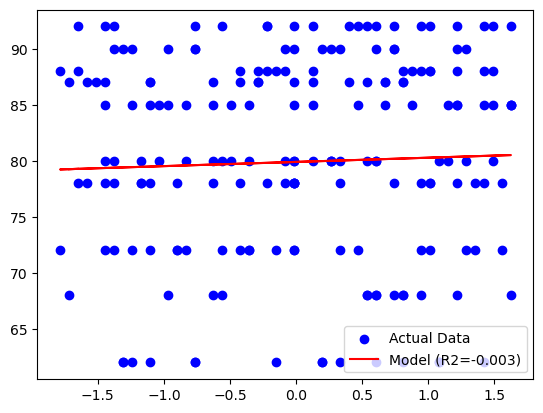

In [22]:
# Initialize the regression model with Lasso regularization (L1)
model_4 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_4.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_4 = model_4.predict(X_test_1)

# Calculate evaluation metrics
mse_4 = np.mean((y_test.reshape(-1, 1) - y_pred_4)**2)  # Mean Squared Error
r2_4 = model_4.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 4: Lasso Regression (Top Feature) ---")

# Print intercept and weights for the top feature
print(f"Intercept (B0): {model_4.B0:.2f}")
print(f"Weight (W) for {top_feature}: {model_4.W.flatten()[0]:.4f}")

print(f"Test MSE: {mse_4:.4f}")
print(f"Test R2: {r2_4:.4f}")

# Plotting the results
model_4.plot(X_test_1, y_test)

Case 5: Lasso Regression (All Features)

In [25]:
# Initialize the regression model with Lasso regularization (L1)
model_5 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_5.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_5 = model_5.predict(X_test_2)

# Calculate evaluation metrics
mse_5 = np.mean((y_test.reshape(-1, 1) - y_pred_5)**2)  # Mean Squared Error
r2_5 = model_5.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 5: Lasso Regression (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_5.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_5.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_5:.4f}")
print(f"Test R2: {r2_5:.4f}")

--- Case 5: Lasso Regression (Using All Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
Gender: -0.4350
StudyHoursPerWeek: 0.0368
PreviousGrade: 0.0103
ExtracurricularActivities: -0.5346
ParentalSupport: -0.3023
Attendance (%): 0.3929
Online Classes Taken: 0.0135
Test MSE: 80.0262
Test R2: -0.0064


Case 6: Lasso Regression (Selected Domain Features)

In [24]:
# Initialize the regression model with Lasso regularization (L1)
model_6 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_6.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_6 = model_6.predict(X_test_3)

# Calculate evaluation metrics
mse_6 = np.mean((y_test.reshape(-1, 1) - y_pred_6)**2)  # Mean Squared Error
r2_6 = model_6.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 6: Lasso Regression (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_6.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_6.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_6:.4f}")
print(f"Test R2: {r2_6:.4f}")

--- Case 6: Lasso Regression (Selected Domain Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
PreviousGrade: 0.0274
Attendance (%): 0.3745
StudyHoursPerWeek: 0.0412
Test MSE: 79.6661
Test R2: -0.0018


Case 7: Ridge Regression (Top Feature)

--- Case 7: Ridge Regression (Top Feature) ---
Intercept (B0): 79.91
Weight (W) for Attendance (%): 0.3765
Test MSE: 79.7839
Test R2: -0.0033


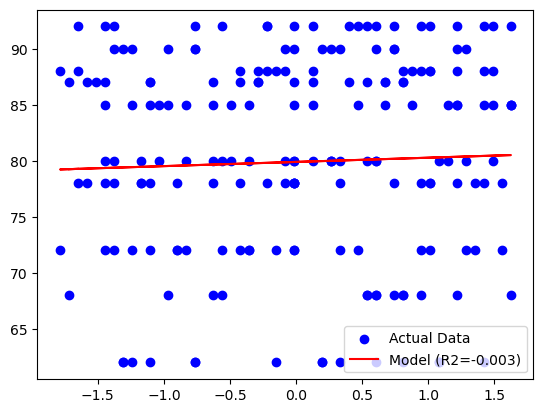

In [31]:
# Initialize the regression model with Ridge regularization (L2)
model_7 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_7.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_7 = model_7.predict(X_test_1)

# Calculate evaluation metrics
mse_7 = np.mean((y_test.reshape(-1, 1) - y_pred_7)**2)  # Mean Squared Error
r2_7 = model_7.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 7: Ridge Regression (Top Feature) ---")

# Print intercept and weights for the top feature
print(f"Intercept (B0): {model_7.B0:.2f}")
print(f"Weight (W) for {top_feature}: {model_7.W.flatten()[0]:.4f}")

print(f"Test MSE: {mse_7:.4f}")
print(f"Test R2: {r2_7:.4f}")

# Plotting the results
model_7.plot(X_test_1, y_test)

Case 8: Ridge Regression (All Features)

In [32]:
# Initialize the regression model with Ridge regularization (L2)
model_8 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_8.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_8 = model_8.predict(X_test_2)

# Calculate evaluation metrics
mse_8 = np.mean((y_test.reshape(-1, 1) - y_pred_8)**2)  # Mean Squared Error
r2_8 = model_8.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 8: Ridge Regression (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_8.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_8.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_8:.4f}")
print(f"Test R2: {r2_8:.4f}")

# Plot (less meaningful for multiple features, but included for consistency)
model_8.plot(X_test_2, y_test)

--- Case 8: Ridge Regression (Using All Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
Gender: -0.4350
StudyHoursPerWeek: 0.0368
PreviousGrade: 0.0104
ExtracurricularActivities: -0.5346
ParentalSupport: -0.3024
Attendance (%): 0.3929
Online Classes Taken: 0.0136
Test MSE: 80.0260
Test R2: -0.0064
Plotting is only supported for Simple Linear Regression.


Case 9: Ridge Regression (Selected Domain Features)

In [33]:
# Initialize the regression model with Ridge regularization (L2)
model_9 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_9.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_9 = model_9.predict(X_test_3)

# Calculate evaluation metrics
mse_9 = np.mean((y_test.reshape(-1, 1) - y_pred_9)**2)  # Mean Squared Error
r2_9 = model_9.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 9: Ridge Regression (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_9.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_9.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_9:.4f}")
print(f"Test R2: {r2_9:.4f}")

# Plot (less meaningful for multiple features, but included for consistency)
model_9.plot(X_test_3, y_test)

--- Case 9: Ridge Regression (Selected Domain Features) ---
Intercept (B0): 79.91
Weights (W) for each feature:
PreviousGrade: 0.0274
Attendance (%): 0.3745
StudyHoursPerWeek: 0.0413
Test MSE: 79.6660
Test R2: -0.0018
Plotting is only supported for Simple Linear Regression.
